In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import cycle
import data_process

In [2]:
with open('output/actions.pkl', 'rb') as f:
    actions = pickle.load(f)
actions

tensor([[15,  0, 41, 33, 34, 47,  6, 66, 67, 43,  9, 25, 68, 65,  0, 69, 32, 27,
         37, 73, 63, 16, 71,  2, 57, 59, 36, 35, 70,  0, 10, 54, 56, 49, 42, 11,
         60, 38, 31, 20,  5, 26,  0,  8, 62, 19, 45, 23, 24, 48, 58, 44, 55, 72,
         29, 21,  0,  7, 64, 50, 39, 30, 28, 40, 51, 52, 53,  0,  4,  3, 12, 13,
         17, 22,  1, 14, 46, 18, 61,  0,  0,  0]])

In [3]:
# data_path = "3t_data/b2d8731b-4d6f-4e1d-80cf-c46ef29908e9.json"
data_path = "3t_data/184d181a-0630-49a7-b8c5-2f94f634ee3e.json" # 76
# data_path = "3t_data/208244c0-8aee-4bc0-971e-ae8909428301.json" # 46
with open(data_path, "r") as file:
    data = json.load(file)
variant = data["variant"]
biggest_equipment = data["biggest_equipment"]
unit_type = data["unit_type"]
num_stack = data["num_stack"]
req_id = data["req_id"]
#
equipment = pd.DataFrame(data["equipment_list"])
equipment = equipment[equipment.name == biggest_equipment]
capacity = equipment[equipment.name == biggest_equipment]["volume"].values[0]
#
df = pd.DataFrame(data["order"])
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str)
df["dest_name"] = df["dest_name"] + "_" + df["dest_id"] + "_" + df["order_number"]
df["collection_date"] = pd.to_datetime(df["collection_date"], format="%Y-%m-%d")
df["volume"] = (
    df["quantity"] * df["height"] / 1000 * df["length"] / 1000 * df["width"] / 1000
)
df["stackable"] = df.apply(
    lambda row: (
        1 if (row["stack_on_top"] == "Y" and row["stack_on_other"] == "Y") else 0
    ),
    axis=1,
)
(
    locations,
    order_id,
    full_load_route,
    dest_names,
    coordinates,
    weights,
    volumes,
    pallets,
    distances,
    time_windows,
    durations,
    speed,
) = data_process.process_account(
    df,
    num_stack=num_stack,
    equipment=equipment,
    biggest_equipment=biggest_equipment,
    unit_type=unit_type,
    variant=variant,
    req_id=req_id,
)

==========PROCESS ACCOUNT ORDERS = DONE==========


In [4]:
locations

,source_name,dest_name,source_lat,source_long,dest_lat,dest_long,weight,volume,delivery_time_start,delivery_time_end,...,length,width,unit_id,proxy_volume,proxy_pse,delivery_start_minutes_of_day,delivery_end_minutes_of_day,over_weight,over_volume,over_pallet
0,Ultra Finishing (Bolton) Ltd,Angela McIver_90649e7a-9da9-4bee-a93e-1c86dc7a...,53.567226,-2.411376,53.426790,-2.960445,85.0,0.211212,00:00:00,08:00:00,...,"[155.0, 170.0, 940.0]","[455.0, 135.0, 940.0]","[9bb71c9d-4852-4a99-bca4-57e75db32115, 54042ff...",0.211212,0.0,0,480,0.068826,0.022233,0.0
1,Ultra Finishing (Bolton) Ltd,B Danby & Co (Anlaby)_37945215-7353-4e1e-a340-...,53.567226,-2.411376,53.747204,-0.424514,89.0,0.431421,00:00:00,08:00:00,...,"[330.0, 275.0, 285.0, 102.0, 50.0, 790.0, 560....","[220.0, 225.0, 240.0, 38.0, 212.0, 160.0, 110....","[acc1483a-7907-4b12-8adb-c67e81f691be, 79cbd3e...",0.431421,0.0,0,480,0.072065,0.045413,0.0
2,Ultra Finishing (Bolton) Ltd,BATHROOM DISTRIBUTION GROUP UK LTD_f495f404-df...,53.567226,-2.411376,53.590750,-2.568105,1.0,0.005940,00:00:00,08:00:00,...,[180.0],[110.0],[6970bbeb-a310-4c91-bcbc-71d8840581eb],0.005940,0.0,0,480,0.000810,0.000625,0.0
3,Ultra Finishing (Bolton) Ltd,BATHROOM DISTRIBUTION GROUP UK LTD_f495f404-df...,53.567226,-2.411376,53.590750,-2.568105,4.0,0.069720,00:00:00,08:00:00,...,[480.0],[415.0],[6f11f80e-0930-4f84-8aad-23a459250280],0.069720,0.0,0,480,0.003239,0.007339,0.0
4,Ultra Finishing (Bolton) Ltd,Bath Time Ltd_6dc78dc4-4194-4dd2-9e32-7f2c23ad...,53.567226,-2.411376,52.930103,-1.218917,112.0,0.359716,00:00:00,08:00:00,...,"[1240.0, 110.0, 420.0, 170.0]","[840.0, 635.0, 770.0, 135.0]","[695a98a2-c637-470d-8f39-f20b0aad12e9, 77333fd...",0.359715,0.0,0,480,0.090688,0.037865,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,Ultra Finishing (Bolton) Ltd,Ultra Finishing Ltd_ae53667d-1c82-46c7-b722-c4...,53.567226,-2.411376,53.721943,-1.885702,21.0,0.183157,00:00:00,07:00:00,...,[835.0],[535.0],[83da9d09-c1f6-44cb-8f8e-91fec9113ccd],0.183157,0.0,0,420,0.017004,0.019280,0.0
69,Ultra Finishing (Bolton) Ltd,W H Halmshaw Ltd_e68616d2-f2da-493c-91a6-f4687...,53.567226,-2.411376,53.733250,-0.359849,28.0,0.069888,00:00:00,08:00:00,...,[1040.0],[840.0],[46c7db91-a27e-41b7-b4dd-40a807b3f7f2],0.069888,0.0,0,480,0.022672,0.007357,0.0
70,Ultra Finishing (Bolton) Ltd,Watermark Plumbing Supplies_4d296c5c-5f69-4f36...,53.567226,-2.411376,53.960945,-1.067446,23.0,0.025212,00:00:00,08:00:00,...,"[800.0, 35.0]","[700.0, 17.0]","[997b518a-0cf1-4b91-83f3-5f027f7b5304, 8dea782...",0.025212,0.0,0,480,0.018623,0.002654,0.0
71,Ultra Finishing (Bolton) Ltd,james murphy_3e83a366-ad5d-4132-9c1b-2e9cec35e...,53.567226,-2.411376,52.389140,-1.787967,54.0,0.151706,00:00:00,07:00:00,...,[435.0],[450.0],[dd56b1b5-b41a-4bbd-b1bc-c0e4637b66a9],0.151706,0.0,0,420,0.043725,0.015969,0.0


In [5]:
def seq_to_routes(seq, drop_empty_routes=True):
    """
    Core logic: Converts a single 1D sequence into a list of routes.
    Each route is guaranteed to be [0, ..., 0].
    """
    routes = []
    cur = []
    for n in seq:
        n = int(n)
        if n == 0:
            if cur:
                routes.append([0] + cur + [0])
                cur = []
            elif not drop_empty_routes:
                routes.append([0, 0])
        else:
            cur.append(n)
    
    # Handle leftover customers if the sequence didn't end with a 0
    if cur:
        routes.append([0] + cur + [0])
        
    return routes

def extract_routes_from_actions(actions, drop_empty_routes=True, is_open=False):
    """
    Parse giant-tour actions into per-route lists. 
    
    Args:
        actions: 1D or 2D Tensor/list. If 2D, shape [batch, seq_len].
        drop_empty_routes: if True, omit routes that contain no customers (i.e., [0] or [0, 0]).
        is_open: if True, routes end at the last customer (e.g., [0, 1, 2]). 
                 if False, routes return to the depot (e.g., [0, 1, 2, 0]).
    Returns:
        If input was 1D: list[list[int]] of routes.
        If input was 2D: list of batches -> list[list[list[int]]].
    """
    single = False
    if isinstance(actions, torch.Tensor):
        actions = actions.cpu()
        if actions.dim() == 1:
            actions = actions.unsqueeze(0)
            single = True
    elif isinstance(actions, (list, tuple)):
        if len(actions) > 0 and not isinstance(actions[0], (list, tuple)):
            actions = [list(actions)]
            single = True
    else:
        raise TypeError("actions must be a tensor or an iterable")
    routes_batch = []
    for seq in actions:
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
        seq = [int(x) for x in seq]
        # Split on zeros
        segments = []
        curr = []
        for val in seq:
            if val == 0:
                segments.append(curr)
                curr = []
            else:
                curr.append(val)
        if curr:
            segments.append(curr)
        # Convert segments to routes
        routes = []
        for seg in segments:
            # Skip empty routes if requested
            if len(seg) == 0 and drop_empty_routes:
                continue
            # Start at depot
            route = [0] + seg
            # If it's a closed route, return to depot
            if not is_open:
                route.append(0)
            routes.append(route)
        routes_batch.append(routes)
    return routes_batch[0] if single else routes_batch

def batch_env_selected_to_routes(env):
    """
    High-level wrapper for the environment object.
    Uses selected_node_list shape (batch, pomo, seq_len).
    """
    sel = env.selected_node_list.cpu().numpy()
    B, P, L = sel.shape
    out = [[None] * P for _ in range(B)]
    for b in range(B):
        for p in range(P):
            out[b][p] = seq_to_routes(sel[b, p, :])
    return out

# --- Cost Calculation Utilities ---

def route_length(route, distance_matrix):
    if len(route) < 2: return 0.0
    return sum(distance_matrix[route[i], route[i+1]] for i in range(len(route)-1))

def route_duration(route, duration_matrix):
    if len(route) < 2: return 0.0
    return sum(duration_matrix[route[i], route[i+1]] for i in range(len(route)-1))

def choose_best_pomo(routes_per_pomo, distance_matrix=None, duration_matrix=None, 
                     coords_with_depot=None, use_duration=False):
    """
    Calculates total cost for a set of routes and returns (total_cost, routes).
    """
    if use_duration and duration_matrix is not None:
        total = sum(route_duration(r, duration_matrix) for r in routes_per_pomo)
    elif distance_matrix is not None:
        total = sum(route_length(r, distance_matrix) for r in routes_per_pomo)
    elif coords_with_depot is not None:
        total = 0.0
        for route in routes_per_pomo:
            pts = coords_with_depot[route]
            total += np.linalg.norm(pts[1:] - pts[:-1], axis=1).sum()
    else:
        raise ValueError("Missing distance_matrix, duration_matrix, or coords_with_depot")
    
    return total, routes_per_pomo

In [6]:
is_open = True
routes = extract_routes_from_actions(actions, is_open=is_open)
print(routes[0])
print(len(routes[0]))

[[0, 15], [0, 41, 33, 34, 47, 6, 66, 67, 43, 9, 25, 68, 65], [0, 69, 32, 27, 37, 73, 63, 16, 71, 2, 57, 59, 36, 35, 70], [0, 10, 54, 56, 49, 42, 11, 60, 38, 31, 20, 5, 26], [0, 8, 62, 19, 45, 23, 24, 48, 58, 44, 55, 72, 29, 21], [0, 7, 64, 50, 39, 30, 28, 40, 51, 52, 53], [0, 4, 3, 12, 13, 17, 22, 1, 14, 46, 18, 61]]
7


In [7]:
def compute_schedule(
    route,                  # list of location indices (including depot)
    travel_time_matrix,     # 2D list or numpy array
    service_durations,      # list indexed by location
    time_windows,           # list of (start, end)
    start_time=0
):
    schedule = []
    current_time = start_time
    for i in range(len(route)):
        loc = route[i]
        if i == 0:
            # Depot start
            arrival = current_time
        else:
            prev = route[i - 1]
            travel_time = travel_time_matrix[prev][loc]
            arrival = current_time + travel_time
        tw_start, tw_end = time_windows[loc]
        # Waiting if early
        wait = max(0, tw_start - arrival)
        # Start service
        start_service = arrival + wait
        # Departure time
        service_duration = service_durations if loc != 0 else 0
        departure = start_service + service_duration
        # Time warp (late arrival)
        time_warp = max(0, arrival - tw_end)
        schedule.append({
            "location": loc,
            "arrival": arrival,
            "wait": wait,
            "start_service": start_service,
            "departure": departure,
            "time_warp": time_warp,
        })
        # Move time forward
        current_time = departure
    return schedule

In [8]:
schedule = compute_schedule(
    routes[0][0],
    durations,
    10,
    time_windows,
    start_time=0
)
for s in schedule:
    print(s)

{'location': 0, 'arrival': 0, 'wait': 0, 'start_service': 0, 'departure': 0, 'time_warp': 0}
{'location': 15, 'arrival': 56, 'wait': 0, 'start_service': 56, 'departure': 66, 'time_warp': 0}


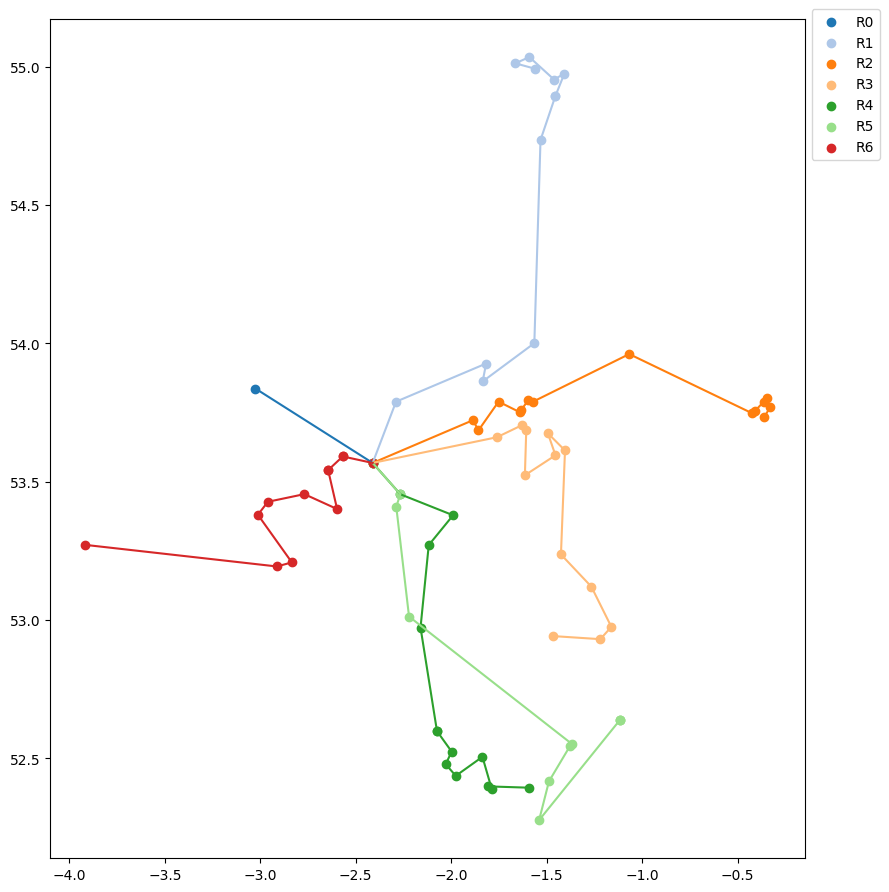

In [9]:
def route_visualize(coordinates, routes):
    coordinates = pd.DataFrame(coordinates, columns=["x", "y"])
    num_location = coordinates.shape[0]
    #
    cmap = mpl.colormaps["tab20"]
    colors = cycle(cmap.colors)
    # Now the figure
    figsize = [max(int(num_location / 8), 5), max(int(num_location / 8), 5)]
    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    for r, tour in enumerate(routes):
        c = next(colors)
        t = np.array(tour)
        x = coordinates.values[t, 0]
        y = coordinates.values[t, 1]
        ax.scatter(x, y, color=c, label=f"R{r}")
        ax.plot(x, y, color=c)

    ax.legend(loc="upper left", bbox_to_anchor=(1, 1.02))
    fig.tight_layout()
    plt.show()
    return
route_visualize(coordinates, routes[0])

In [10]:
route_pallet_delivery = []
route_weight_delivery = []
route_volume_delivery = []
route_duration = []
route_distance = []
loc_service_time = 10
for route in routes[0]:
    pallet_delivery, weight_delivery, volume_delivery= 0, 0, 0
    duration = 0
    distance = 0
    for i in range(len(route) -1):
        distance += distances[route[i]][route[i+1]]
        duration += durations[route[i]][route[i+1]] + loc_service_time
        pallet_delivery += pallets[route[i+1]]
        weight_delivery += weights[route[i+1]] 
        volume_delivery += volumes[route[i+1]]
    route_pallet_delivery.append(pallet_delivery)
    route_weight_delivery.append(weight_delivery)
    route_volume_delivery.append(volume_delivery)
    route_duration.append(duration)
    route_distance.append(distance)
print(sum(route_distance))
print(route_pallet_delivery)
print(route_weight_delivery)
print(route_volume_delivery)
print(route_duration)
print(route_distance)

1696
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[25.0, 273.0, 953.0, 478.0, 687.0, 330.0, 397.0]
[0.06988799999999999, 1.6365278499999998, 5.48186169, 2.34405025, 8.52844928, 1.75195945, 1.831209925]
[66, 454, 425, 444, 476, 383, 337]
[67, 308, 244, 298, 282, 301, 196]
